In [19]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-darkgrid")

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [ ]:
df = pd.read_csv("../data/ev_charging_load_forecasting_datasetPORTLogsitics.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (65016, 23)


,Timestamp,Day_of_Week,Holiday_Indicator,Fleet_Size,Vehicle_Types,Average_Battery_Capacity_kWh,Number_of_Charging_Stations,Charging_Power_Rating_kW,Charging_Efficiency,Total_Distance_Driven_km,...,Humidity_%,Precipitation_mm,Previous_Charging_Loads_kW,Charging_Duration_hours,Electricity_Prices_USD,Grid_Demand_MW,Incentives_Programs,Charging_Preferences,EV_Usage_Patterns,Charging_Load_kW
0,2020-12-18 05:00:00,4,0,5,Light-Duty,150,3,7.2,0.875531,7,...,69.725151,0,10,0.5,0.203290,91.061101,1,Night,Medium,14
1,2022-03-01 12:00:00,4,0,5,Light-Duty,50,1,22.5,0.761737,0,...,59.785463,0,10,0.5,0.282706,102.042863,0,Night,High,21
2,2023-09-12 20:00:00,1,0,5,Heavy-Duty,50,4,50.0,0.813927,1,...,58.944489,0,10,1.0,0.430902,108.767360,0,Day,High,0
3,2020-08-03 16:00:00,3,0,10,Light-Duty,150,2,22.5,0.816037,0,...,96.832030,0,10,1.5,0.455454,87.720937,0,Day,Low,91
4,2024-05-22 08:00:00,2,0,5,Light-Duty,50,4,22.5,0.792259,0,...,70.588628,10,10,1.0,0.118778,68.889408,0,Night,High,12


In [21]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

df['Hour'] = df['Timestamp'].dt.hour
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek
df['Month'] = df['Timestamp'].dt.month

df['IsPeakHour'] = df['Hour'].isin([8,9,10,18,19,20]).astype(int)
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)

In [22]:
df['Charging_Intensity'] = df['Charging_Duration_hours'] * df['Charging_Power_Rating_kW']

df['Fleet_Utilization'] = df['Fleet_Size'] * df['Total_Distance_Driven_km']

df['Demand_Stress'] = df['Previous_Charging_Loads_kW'] / (df['Grid_Demand_MW'] + 1)

df['User_Behaviour_Score'] = (
    df['Charging_Intensity'] +
    df['Fleet_Utilization'] * 0.0001
)

In [23]:
df['Lag1'] = df['Charging_Load_kW'].shift(1)
df['Lag2'] = df['Charging_Load_kW'].shift(2)
df['Lag3'] = df['Charging_Load_kW'].shift(3)

df['RollingMean6'] = df['Charging_Load_kW'].rolling(6).mean()
df['RollingStd6'] = df['Charging_Load_kW'].rolling(6).std()

df = df.dropna()

In [24]:
cat_cols = [
    'Vehicle_Types',
    'Charging_Preferences',
    'Incentives_Programs',
    'EV_Usage_Patterns'
]

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [25]:
X = df.drop(['Charging_Load_kW', 'Timestamp'], axis=1)
y = df['Charging_Load_kW']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

In [28]:
rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=18,
    min_samples_split=5,
    random_state=42
)

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

In [29]:
xgb = XGBRegressor(
    n_estimators=400,
    learning_rate=0.03,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8
)

xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)

In [30]:
def evaluate(y_true, y_pred, name):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print("MAE :", round(mae,3))
    print("RMSE :", round(rmse,3))
    print("R2 :", round(r2,4))

In [31]:
evaluate(y_test, pred_lr, "Linear Regression")
evaluate(y_test, pred_rf, "Behaviour RF Model")
evaluate(y_test, pred_xgb, "XGBoost Model")


Linear Regression
MAE : 17.916
RMSE : 24.757
R2 : 0.3314

Behaviour RF Model
MAE : 18.247
RMSE : 25.276
R2 : 0.303

XGBoost Model
MAE : 18.06
RMSE : 25.176
R2 : 0.3086


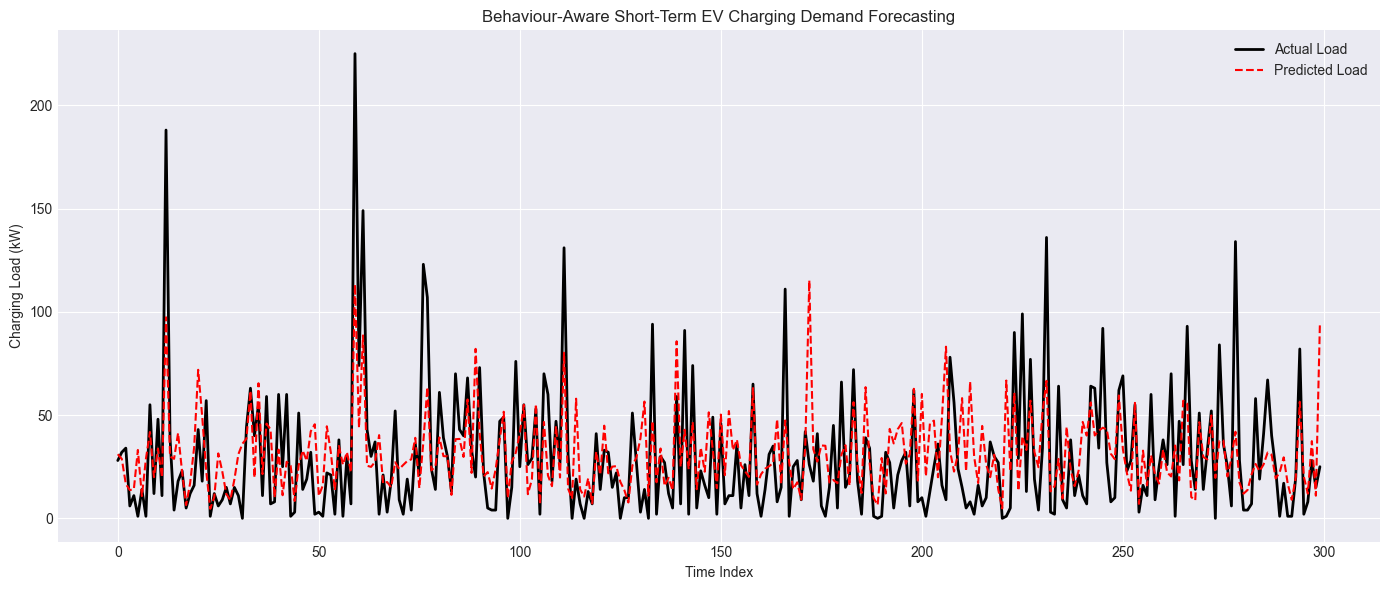

In [32]:
plt.figure(figsize=(14,6))

plt.plot(y_test.values[:300], color='black', linewidth=2, label='Actual Load')
plt.plot(pred_rf[:300], color='red', linestyle='--', label='Predicted Load')

plt.xlabel("Time Index")
plt.ylabel("Charging Load (kW)")
plt.title("Behaviour-Aware Short-Term EV Charging Demand Forecasting")
plt.legend()
plt.tight_layout()
plt.show()

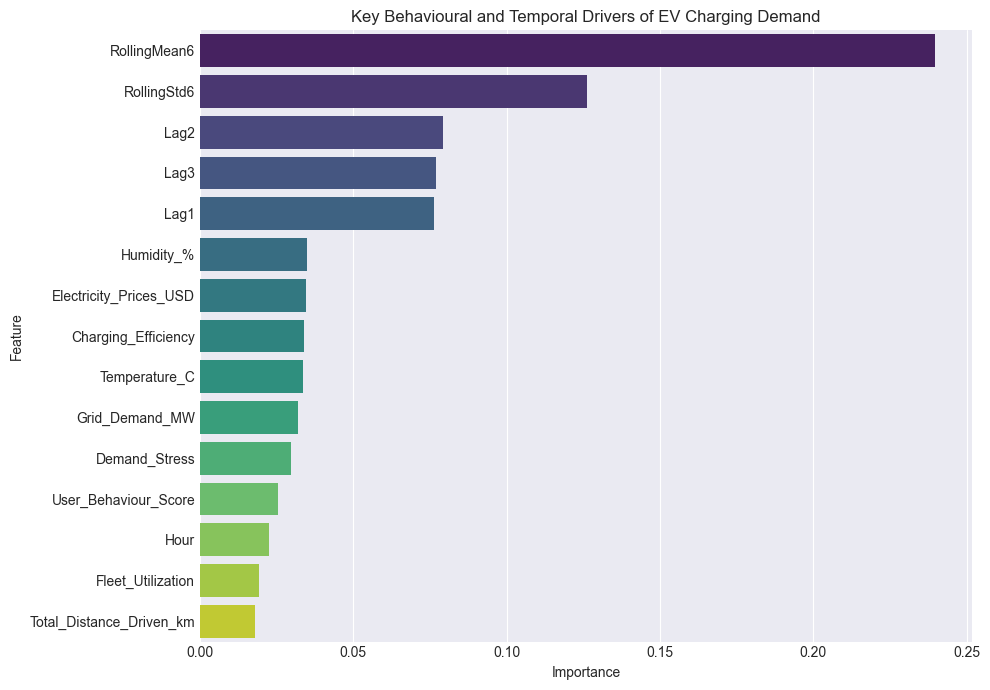

In [33]:
importance = rf.feature_importances_

imp_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,7))
sns.barplot(
    x='Importance',
    y='Feature',
    data=imp_df.head(15),
    palette="viridis"
)

plt.title("Key Behavioural and Temporal Drivers of EV Charging Demand")
plt.tight_layout()
plt.show()

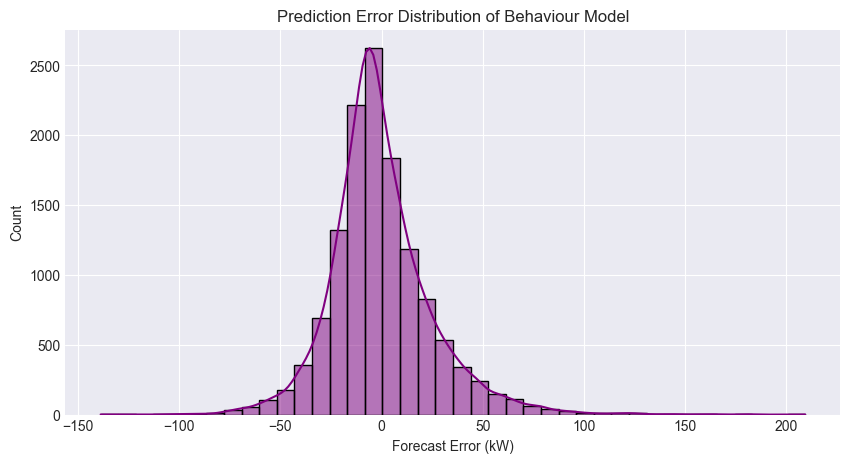

In [34]:
error = y_test - pred_rf

plt.figure(figsize=(10,5))
sns.histplot(error, bins=40, kde=True, color='purple')

plt.title("Prediction Error Distribution of Behaviour Model")
plt.xlabel("Forecast Error (kW)")
plt.show()

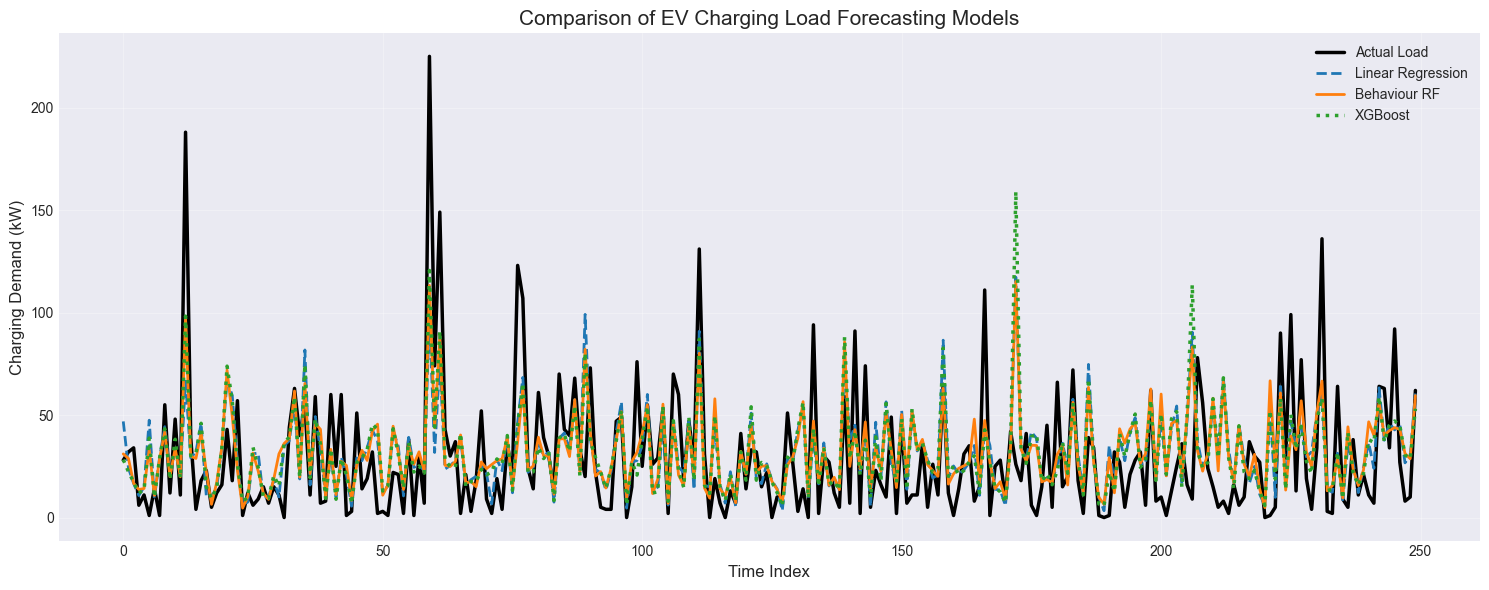

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(y_test.values[:250],
         color='black',
         linewidth=2.5,
         label='Actual Load')

plt.plot(pred_lr[:250],
         linestyle='--',
         linewidth=2,
         label='Linear Regression')

plt.plot(pred_rf[:250],
         linestyle='-',
         linewidth=2,
         label='Behaviour RF')

plt.plot(pred_xgb[:250],
         linestyle=':',
         linewidth=2.5,
         label='XGBoost')

plt.title("Comparison of EV Charging Load Forecasting Models",
          fontsize=15)

plt.xlabel("Time Index", fontsize=12)
plt.ylabel("Charging Demand (kW)", fontsize=12)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

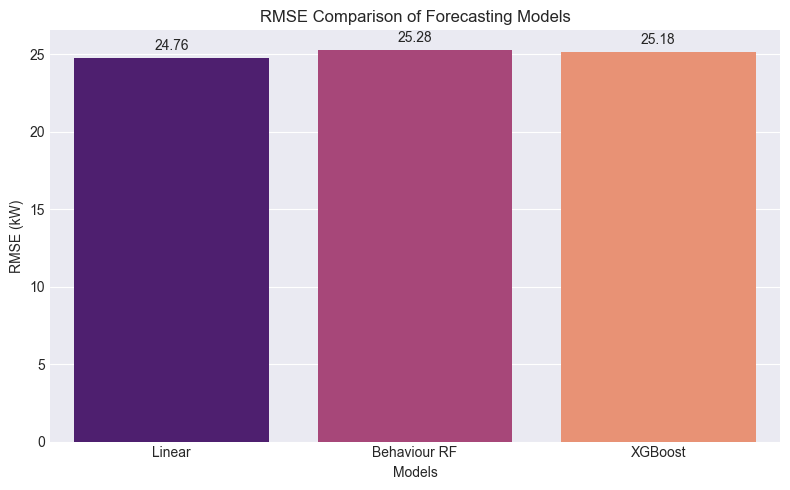

In [ ]:
from sklearn.metrics import mean_squared_error

rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))

models = ['Linear', 'Behaviour RF', 'XGBoost']
rmse_values = [rmse_lr, rmse_rf, rmse_xgb]

plt.figure(figsize=(8,5))

sns.barplot(x=models, y=rmse_values, palette='magma')

plt.title("RMSE Comparison of Forecasting Models")
plt.ylabel("RMSE (kW)")
plt.xlabel("Models")

for i, v in enumerate(rmse_values):
    plt.text(i, v + 0.5, round(v,2), ha='center')

plt.tight_layout()
plt.show()

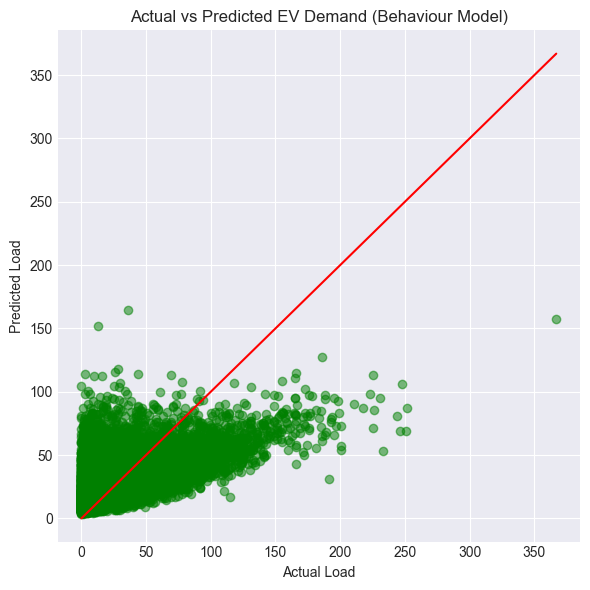

In [37]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, pred_rf,
            alpha=0.5,
            color='green')

plt.xlabel("Actual Load")
plt.ylabel("Predicted Load")
plt.title("Actual vs Predicted EV Demand (Behaviour Model)")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.tight_layout()
plt.show()